# Prepare the features

- BOP features arrangement and averagings
- Library Features arrangement ad averaging
- Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize = (15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)
import copy
import os
import numpy as np
import pdb
from tqdm.auto import tqdm 
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Cr-Co-W/'
descriptorlocation = os.path.join(dataset, 'Descriptors')

import pdb

# Load Features 

In [2]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'pyscal_steinhardt.kpl')
BopFeaturesFile = os.path.join(descriptorlocation, 'CrCoW_initial_canonical_table_WUBIND_16.pkl')
AtomicFeaturesFile = os.path.join(descriptorlocation, 'matminer_atomic_features.pkl')
CompositionFeaturesFile = os.path.join(descriptorlocation, 'matminer_composition_features.pkl')

PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = pd.read_pickle(BopFeaturesFile)
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Arrangement and averaging BOP Features 

In [3]:
BopFeatures

,U_bind,U_bond_atom,U_bond_atom_list,moments,normed_moments,an,bn,sigma,Ainf,Binf
Co_pv6W_sv6.C14-BBA.FM,-58.644616,-78.588438,"[-4.3975143698, -4.3975143698, -4.3975143698, ...","[[0.0, 1.30409, -0.634205, 4.08953, -4.29737, ...","[[0.0717862986, 0.0843546428, 0.0079343959, 0....","[[0.0, -0.48632200000000003, -0.22576999999999...","[[0.0, 1.14197, 1.26307, 1.51045, 1.71511, 1.7...","[[1.0, 0.143370955, -0.6601173127, -0.22212161...","[-0.2912918773, -0.2912918773, -0.2912918773, ...","[2.0288821321, 2.0288821321, 2.0288821321, 2.0..."
Co_pv6W_sv6.C14-BBA.NM,-58.644616,-78.588438,"[-4.3975143698, -4.3975143698, -4.3975143698, ...","[[0.0, 1.30409, -0.634205, 4.08953, -4.29737, ...","[[0.0717862986, 0.0843546428, 0.0079343959, 0....","[[0.0, -0.48632200000000003, -0.22576999999999...","[[0.0, 1.14197, 1.26307, 1.51045, 1.71511, 1.7...","[[1.0, 0.143370955, -0.6601173127, -0.22212161...","[-0.2912918773, -0.2912918773, -0.2912918773, ...","[2.0288821321, 2.0288821321, 2.0288821321, 2.0..."
Cr_pv6W_sv2.D0_19-A3B.FM,-42.039279,-42.05443,"[-5.3205290305, -5.3211668379, -5.3205290069, ...","[[0.0, 1.55611, -0.46190499999999995, 4.3839, ...","[[0.1014238266, 0.2121465775, 0.0408827474, 0....","[[0.0, -0.296833, -0.469329, -0.400833, -0.563...","[[0.0, 1.24744, 1.08305, 1.15153, 1.18244, 1.2...","[[1.0, 0.2025627613, -0.1508505882, -0.0780889...","[-0.2816017388, -0.2816017668, -0.2816209469, ...","[1.3882425276, 1.3882425434, 1.3883516161, 1.3..."
Cr_pv6W_sv2.D0_19-A3B.NM,-42.039279,-42.05443,"[-5.3205290305, -5.3211668379, -5.3205290069, ...","[[0.0, 1.55611, -0.46190499999999995, 4.3839, ...","[[0.1014238266, 0.2121465775, 0.0408827474, 0....","[[0.0, -0.296833, -0.469329, -0.400833, -0.563...","[[0.0, 1.24744, 1.08305, 1.15153, 1.18244, 1.2...","[[1.0, 0.2025627613, -0.1508505882, -0.0780889...","[-0.2816017388, -0.2816017668, -0.2816209469, ...","[1.3882425276, 1.3882425434, 1.3883516161, 1.3..."
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-143.858275,-177.797933,"[-5.6783573351, -5.6783573351, -5.6783573351, ...","[[0.0, 1.6417299999999997, -0.514678, 4.64595,...","[[0.0511669029, 0.1742224999, 0.0090822449, 0....","[[0.0, -0.313498, -0.0932309, -0.316523, -0.13...","[[0.0, 1.2813, 1.04399, 1.22413, 1.20185, 1.29...","[[1.0, 0.10219008189999998, -0.3019827453, -0....","[-0.158261488, -0.158261488, -0.158261488, -0....","[1.5465220577, 1.5465220577, 1.5465220577, 1.5..."
...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,-73.831298,-74.435034,"[-6.9191485421, -6.919148542, -6.9191513819, -...","[[0.0, 2.32545, -0.791208, 9.27675, -7.1620900...","[[0.0938956088, 0.1856862941, 0.0340534405, 0....","[[0.0, -0.340239, -0.261418, -0.680929, -0.326...","[[0.0, 1.52494, 1.24419, 1.6427599999999998, 1...","[[1.0, 0.1875274718, -0.2562981024, -0.1024407...","[-0.3404644258, -0.1911202335, -0.1911202335, ...","[1.8129944001, 1.7889585488, 1.7889585488, 1.7..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-156.777732,-172.917606,"[-5.0627343795, -5.0627343795, -5.0627343795, ...","[[0.0, 1.34753, -0.454488, 3.32921, -2.3634, 1...","[[0.0464940682, 0.1540991271, 0.0040858193, 0....","[[0.0, -0.337275, -0.124542, -0.254523, -0.055...","[[0.0, 1.16083, 1.00465, 1.17859, 1.15633, 1.2...","[[1.0, 0.0928575381, -0.3821768843, -0.1522285...","[-0.1384632371, -0.1384632371, -0.1384632371, ...","[1.4890419619, 1.4890419619, 1.4890419619, 1.4..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-156.777732,-172.917606,"[-5.0627343795, -5.0627343795, -5.0627343795, ...","[[0.0, 1.34753, -0.454488, 3.32921, -2.3634, 1...","[[0.0464940682, 0.1540991271, 0.0040858193, 0....","[[0.0, -0.337275, -0.124542, -0.254523, -0.055...","[[0.0, 1.16083, 1.00465, 1.17859, 1.15633, 1.2...","[[1.0, 0.0928575381, -0.3821768843, -0.1522285...","[-0.1384632371, -0.1384632371, -0.1384632371, ...","[1.4890419619, 1.4890419619, 1.4890419619, 1.4..."
Co_pv13W_sv16.chi-ABAB.NM,-127.090687,-186.802107,"[-5.1432538134, -5.1432538134, -5.1432538134, ...","[[0.0, 1.39375, -0.697376, 4.37561, -4.

In [4]:
columnstoexpand = BopFeatures.columns.drop(['U_bind','U_bond_atom', 'U_bond_atom_list'])
columnstoexpand

Index(['moments', 'normed_moments', 'an', 'bn', 'sigma', 'Ainf', 'Binf'], dtype='object')

In [5]:
df = gf.array_expansions(BopFeatures, columnstoexpand)

In [6]:
BOPAveraged = gf.cnaverage_dataframe(df, df.columns, PyscalFeatures.pyscal_cn[df.index],)

  0%|          | 0/77 [00:00<?, ?it/s]

In [7]:
gf.cnav_column_name_fix(BOPAveraged)

In [8]:
BOPAveraged = pd.concat(BOPAveraged.values(), axis=1)

In [9]:
BOPAveraged

,moments_1_0,moments_1_CN12,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,moments_2_CN14,moments_2_CN15,moments_2_CN16,...,sigma_14_0,sigma_14_CN12,sigma_14_CN14,sigma_14_CN15,sigma_14_CN16,sigma_15_0,sigma_15_CN12,sigma_15_CN14,sigma_15_CN15,sigma_15_CN16
Co_pv6W_sv6.C14-BBA.FM,2.496405,2.061708,0.000000,0.000000,0.434697,-0.957307,-0.745905,0.000000,0.000000,-0.211402,...,-0.098835,-0.088005,0.000000,0.000000,-0.010830,-0.009289,-0.005191,0.000000,0.000000,-0.004098
Co_pv6W_sv6.C14-BBA.NM,2.496405,2.061708,0.000000,0.000000,0.434697,-0.957307,-0.745905,0.000000,0.000000,-0.211402,...,-0.098835,-0.088005,0.000000,0.000000,-0.010830,-0.009289,-0.005191,0.000000,0.000000,-0.004098
Cr_pv6W_sv2.D0_19-A3B.FM,1.530625,1.530625,0.000000,0.000000,0.000000,-0.453207,-0.453207,0.000000,0.000000,0.000000,...,0.019260,0.019260,0.000000,0.000000,0.000000,0.029418,0.029418,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,1.530625,1.530625,0.000000,0.000000,0.000000,-0.453207,-0.453207,0.000000,0.000000,0.000000,...,0.019260,0.019260,0.000000,0.000000,0.000000,0.029418,0.029418,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,1.797828,0.663849,0.945488,0.188491,0.000000,-0.577710,-0.213980,-0.298615,-0.065115,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,1.828545,1.308482,0.197531,0.143759,0.178772,-0.599148,-0.426060,-0.055556,-0.040615,-0.076917,...,-0.047778,-0.047196,-0.000755,0.007952,-0.007779,-0.015776,-0.013269,-0.009275,0.008601,-0.001832
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,1.713707,0.632789,0.901248,0.179671,0.000000,-0.537641,-0.199138,-0.277904,-0.060598,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,1.713707,0.632789,0.901248,0.179671,0.000000,-0.537641,-0.199138,-0.277904,-0.060598,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
Co_pv13W_sv16.chi-ABAB.NM,2.241933,0.000000,0.000000,0.000000,0.266543,-0.751986,0.000000,0.000000,0.000000,-0.120221,...,-0.018872,0.000000,0.000000,0.000000,-0.020892,0.048321,0.000000,0.000000,0.000000,0.002148


In [10]:
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(BopFeaturesFile))

In [11]:
BOPAveraged.to_pickle(averaged_bop_file)

## Averaging Pyscal Features

In [12]:
columnstoexpand = [col for col in PyscalFeatures if 'steinhardt' in col]

In [13]:
PyscalFeaturesAveraged = gf.cnaverage_dataframe(PyscalFeatures, columnstoexpand, PyscalFeatures.pyscal_cn)

  0%|          | 0/2 [00:00<?, ?it/s]

In [14]:
gf.cnav_column_name_fix(PyscalFeaturesAveraged)

In [15]:
PyscalFeaturesAveraged = pd.concat(PyscalFeaturesAveraged.values(), axis = 1)

In [16]:
PyscalFeaturesAveraged.to_pickle(os.path.join(descriptorlocation,f'CNAV_{os.path.basename(PyscalFeaturesFile)}'))

In [17]:
PyscalFeaturesAveraged

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Co_pv6W_sv6.C14-BBA.FM,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Co_pv6W_sv6.C14-BBA.NM,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Cr_pv6W_sv2.D0_19-A3B.FM,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.043541,0.036474,0.004550,0.000248,0.002268,0.478648,0.340808,0.061350,0.045118,0.031371
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.081875,0.000000,0.000000,0.000000,0.005151,0.471315,0.000000,0.000000,0.000000,0.033856


# compiling FULL features 

In [18]:
AllFeatures = [AtomicFeatures,CompositionFeatures,  BOPAveraged, PyscalFeaturesAveraged] # 

In [19]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [20]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [21]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [22]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [23]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [24]:
FullSetOfFeatures[categorical_features_names]

,HOMO_character,HOMO_element,LUMO_character,LUMO_element
Co_pv6W_sv6.C14-BBA.FM,0.0,2.0,0.0,2.0
Co_pv6W_sv6.C14-BBA.NM,0.0,2.0,0.0,2.0
Cr_pv6W_sv2.D0_19-A3B.FM,0.0,2.0,0.0,2.0
Cr_pv6W_sv2.D0_19-A3B.NM,0.0,2.0,0.0,2.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,1.0,1.0,1.0,1.0
...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.0,2.0,0.0,2.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.0,1.0,0.0,1.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.0,1.0,0.0,1.0
Co_pv13W_sv16.chi-ABAB.NM,0.0,2.0,0.0,2.0


# Fix Column Names  

In [25]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [26]:
columns = FullSetOfFeatures.columns

In [27]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [28]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

In [29]:
from sklearn.feature_selection import VarianceThreshold

In [30]:
selector = VarianceThreshold()

In [31]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:104: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:112: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [32]:
selectedfeatures = selector.get_support()

In [33]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [34]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

#  Correlation based feature selection

this is not started even. 

In [35]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [36]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [37]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [38]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [39]:
len(to_drop)

284

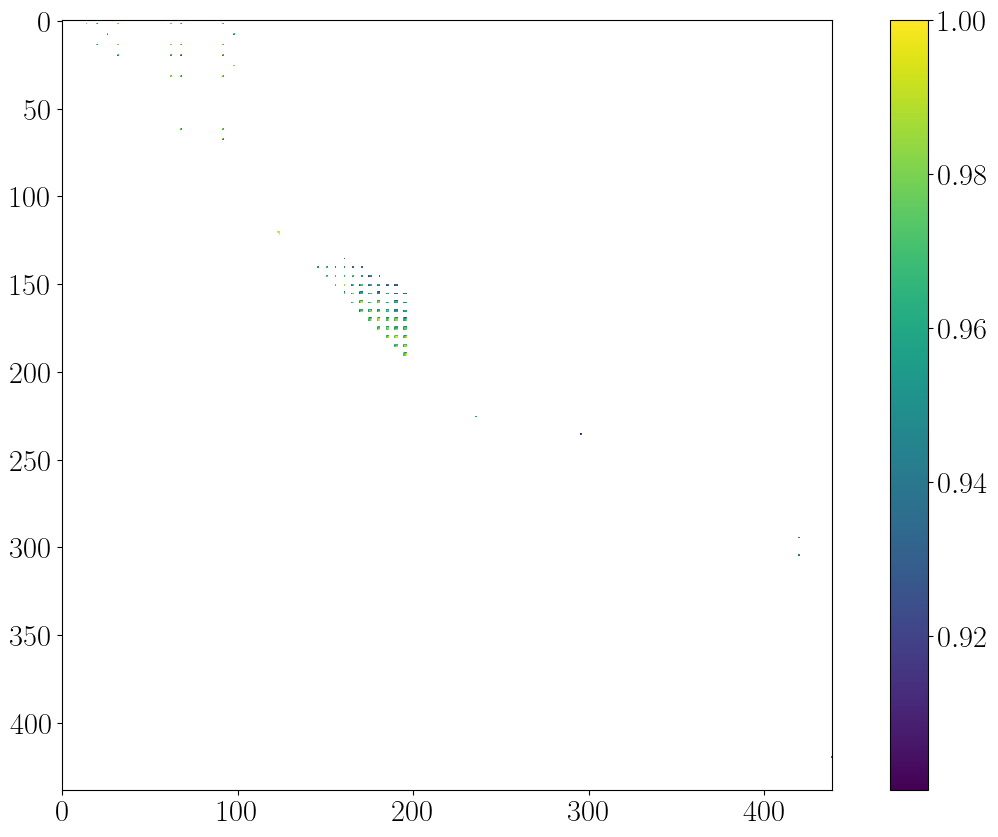

In [40]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

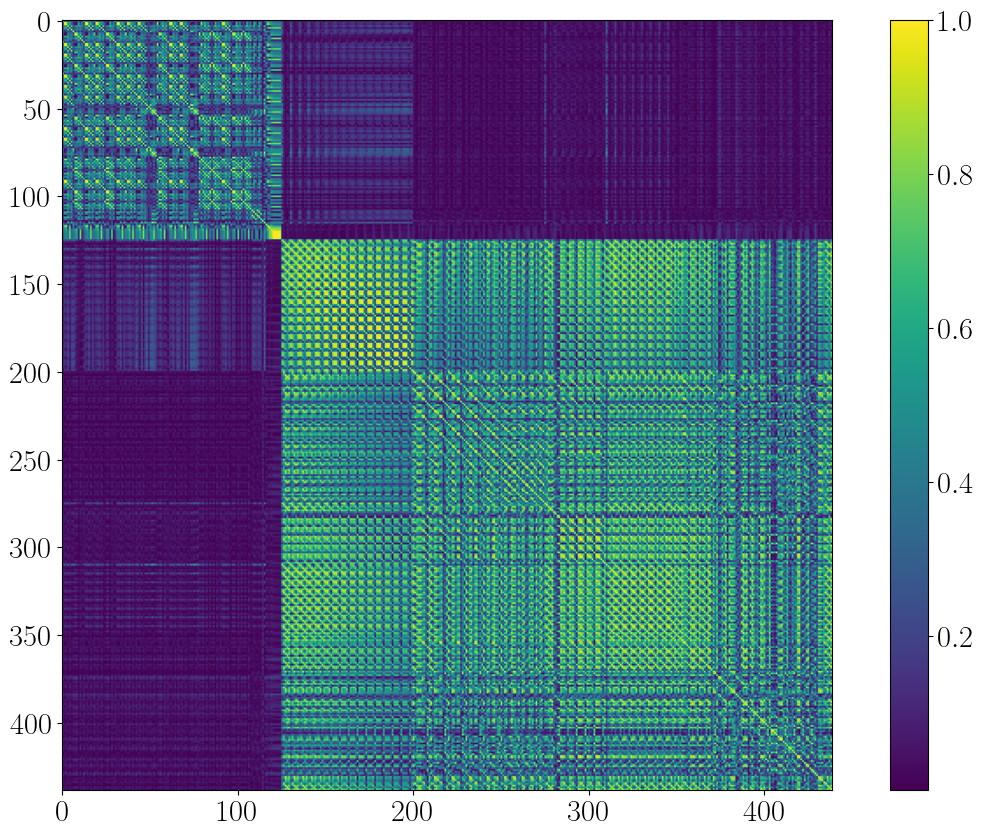

In [41]:
plt.imshow(CORR)
plt.colorbar()